In [41]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [81]:
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random

In [42]:
import matplotlib
from matplotlib.image import NonUniformImage

In [43]:
from eryn.prior import uniform_dist

In [44]:
from bbhx.waveformbuild import BBHWaveformFD
tdi_wave_gen = BBHWaveformFD()


In [45]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13


In [46]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [47]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [48]:
merger_file="blackhole_mergers.hdf5"
merger_data=h5py.File(merger_file, 'r')
M_1=np.maximum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
M_2=np.minimum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
z=np.array(merger_data['time'])**(-1)-1

In [49]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

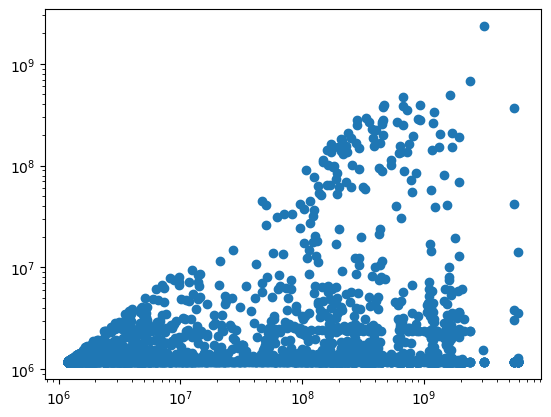

In [50]:
plt.loglog(M_1,M_2,'o')

In [51]:
#wave_gen = PhenomHMAmpPhase()

#parameters from simulation
#m1 = 2e6
#m2 = 7e5
#dist = 15 * 1e9 * PC_SI

#fixed parameters
#chi1 = 0.5
#chi2 = 0.7
#phi_ref = 0.6
#_ref = 0.0
#t_ref = 1e6 # seconds
#length = 1024

#wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

In [52]:
# def wrap(*args, **kwargs):
#     return tdi_wave_gen(*args, **kwargs)[0]
# m1 = M_1[0:50]
# m2 = M_2[0:50]
# dist = d_l
# arr_size= len(m1)
# chi1 = np.full(arr_size, 0.5)
# chi2 = np.full(arr_size, 0.7)
# phi_ref = np.full(arr_size, 0.6)
# f_ref =  np.full(arr_size, 0.0)
# inc =  np.full(arr_size, np.pi / 8)
# lam =  np.full(arr_size, 0.5)
# beta = np.full(arr_size, -0.7)
# psi = np.full(arr_size, np.pi/4)
# t_ref = np.full(arr_size, 1e6) # seconds

# length = 1024

# # setup data holders
# Tobs = YRSID_SI/12   # 1 month
# dt = 10.0  # sec
# N = int(Tobs / dt)
# Tobs = N * dt

# freqs = np.fft.rfftfreq(N, dt)
# AET_gen = tdi_wave_gen(
#         m1,
#         m2, 
#         chi1,
#         chi2,
#         dist, 
#         phi_ref,
#         f_ref, 
#         inc,
#         lam,
#         beta,
#         psi,
#         t_ref,
#         length=1024, 
#         combine=False,  # TODO: check this
#         direct=False,
#         fill=True,
#         squeeze=True,
#         freqs=freqs
#     )
# #snr_tng50=[]
# #for i in range(len(m1)):
# data = DataResidualArray(AET_gen, f_arr=freqs)
# sens_mat = AET1SensitivityMatrix(data.f_arr)
# analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
# snr=analysis.snr()
# #snr_tng50.append(snr)
# print(snr)
# #rint(snr_tng50)

In [53]:
# wave_AET=[]
# for i in range(700):
#     AET_gen = tdi_wave_gen(
#         m1[i],
#         m2[i], 
#         chi1[i],
#         chi2[i],
#         dist[i], 
#         phi_ref[i],
#         f_ref[i], 
#         inc[i],
#         lam[i],
#         beta[i],
#         psi[i],
#         t_ref[i],
#         length=1024, 
#         combine=False,  # TODO: check this
#         direct=False,
#         fill=True,
#         squeeze=True,
#         freqs=freqs
#     )[0]
#     wave_AET.append(AET_gen)
#     #print(AET_gen)

#     #print(AET.shape)
# wave_AET=np.array(wave_AET)
# #print(wave_AET.shape) 

In [54]:
def SNR_calc_test(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(len(M_1), 0.0),
    chi2 = np.full(len(M_1), 0.0),
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
    f_ref = np.full(len(M_1), 0),
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
    lam = uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
    psi = uniform_dist(0.0, np.pi).rvs(len(M_1)),
    t_ref = np.full(len(M_1), 1e6),obs=1,
    num_elements=len(M_1),batch=100):
    #check if the length is same:
   
    assert len(m1) == len(m2) == len(chi1) == len(chi2) == len(dist) == len(phi_ref) == len(f_ref) == len(inc) == len(lam) == len(beta) == len(psi) == len(t_ref), "Array lengths are not equal"
    
    
    # Setup data holders
    Tobs = YRSID_SI / 12*obs   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    batch=batch
   
    for i in range((num_elements + batch - 1) // batch):
        start_i = i * batch
        end_i = min((i + 1) * batch, num_elements)
        
        AET_gen = tdi_wave_gen(
            m1[start_i:end_i],
            m2[start_i:end_i], 
            chi1[start_i:end_i],
            chi2[start_i:end_i],
            dist[start_i:end_i], 
            phi_ref[start_i:end_i],
            f_ref[start_i:end_i], 
            inc[start_i:end_i],
            lam[start_i:end_i],
            beta[start_i:end_i],
            psi[start_i:end_i],
            t_ref[start_i:end_i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
        for j in range(len(AET_gen)):
            data = DataResidualArray(AET_gen[j], f_arr=freqs)
            sens_mat = AET1SensitivityMatrix(data.f_arr)
            analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
            snr = analysis.snr()
            SNR_new.append(snr)

    return SNR_new

In [55]:
#print(wave_AET.shape)

In [56]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
             num_elements = len(M_1)):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


In [57]:
tdi_wave_gen = BBHWaveformFD()
def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc_opt(m1 = M_1, m2 = M_2, dist = d_l,n=1):
    arr_size=len(m1)*n
    m1new = []
    m2new = []
    distnew = []
    for i in range(len(m1)):
        m1new = m1new + [m1[i]]*n
        m2new = m2new + [m2[i]]*n
        distnew = distnew + [dist[i]]*n  

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)    
    phi_ref = np.random.uniform(0.0, 2 * np.pi, arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(np.random.uniform(-1.0, 1.0,arr_size))
    lam = np.random.uniform(0.0, 2 * np.pi, arr_size)
    beta = np.arcsin(np.random.uniform(-1.0, 1.0,arr_size))
    psi = np.random.uniform(0.0,np.pi, arr_size)
    t_ref = np.full(arr_size, 1e6)

    # Setup data holders
    Tobs = YRSID_SI / 12   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)


    SNR_new = []

    for i in range(arr_size):
        AET_gen = tdi_wave_gen(
            m1new[i],
            m2new[i], 
            chi1[i],
            chi2[i],
            distnew[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)
        
    result={
        'm1'  :m1new,
        'm2'  :m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'snr':SNR_new
    }
    return result


In [58]:
#SNR_calc_opt(m1=M_1,m2=M_1,dist=d_l,n=1)

In [59]:
def draw_params(m1 = M_1, m2 = M_2, dist = d_l,n=1): 
                
    arr_size=len(m1)*n
    m1new = []
    m2new = []
    distnew = []
    for i in range(len(m1)):
        m1new = m1new + [m1[i]]*n
        m2new = m2new + [m2[i]]*n
        distnew = distnew + [dist[i]]*n  

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
        'm1'  :m1new,
        'm2'  :m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

In [60]:
# Calling the function
#snr_tng50 = SNR_calc()

In [61]:
#p=draw_params(m1 = M_1, m2 = M_2, dist = d_l,n=1)

In [62]:
#snr_tng50_params_5=SNR_calc(**p)

In [63]:
#print(snr_tng50)
#np.save('snr_tng50_params_5.npy', snr_tng50_params_5)

In [64]:
# with h5py.File('wave_AET.h5', 'w') as hdf_file:
#     hdf_file.create_dataset('wave_AET', data=wave_AET) 

In [65]:
# fn = np.logspace(-6, -1, 10000)
# Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
# plt.loglog(fn, Sn_char_strain)
# plt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label='A')
# plt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label='E')
# plt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label='T')
# plt.legend()

In [66]:
#wave_AET= np.load('wave_AET.npy')


In [67]:
# snr_tng50=[]
# for i in range(700):
#     data = DataResidualArray(wave_AET[i], f_arr=freqs)
#     sens_mat = AET1SensitivityMatrix(data.f_arr)
#     analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#     snr=analysis.snr()
#     snr_tng50.append(snr)
#     #print(snr_tng50)


In [68]:
#snr_tng50=analysis.snr()
#np.save('snr_tng50.npy', snr_tng50)

In [69]:
snr_tng50=np.load('snr_tng50.npy')
snr_tng50_params=np.load('snr_tng50_params.npy')
snr_tng50_params_5=np.load('snr_tng50_params_5.npy')
snr_tng50_old=np.load('snr_tng_50_old.npy')

In [70]:
print(snr_tng50_params)

[5.98272142e+02 5.86754920e+02 2.56982610e+02 ... 4.45234237e+04
 1.40701041e+07 5.77344877e+04]


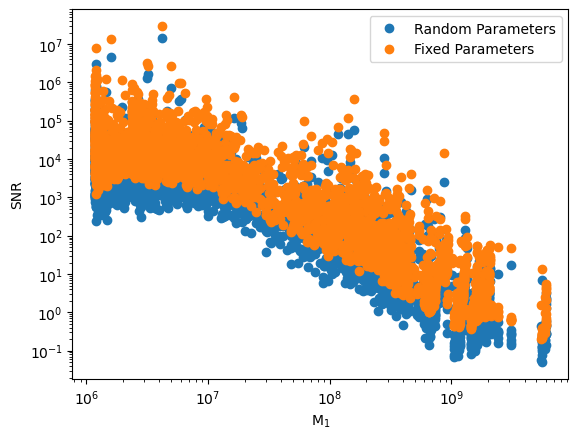

In [71]:
plt.loglog(M_1,snr_tng50_params,'o',label='Random Parameters')
plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

In [72]:
# M_1_new=p['m1']
# M_2_new=p['m2']
# plt.loglog(M_1_new,snr_tng50_params_5,'o',label='Random Parameters')

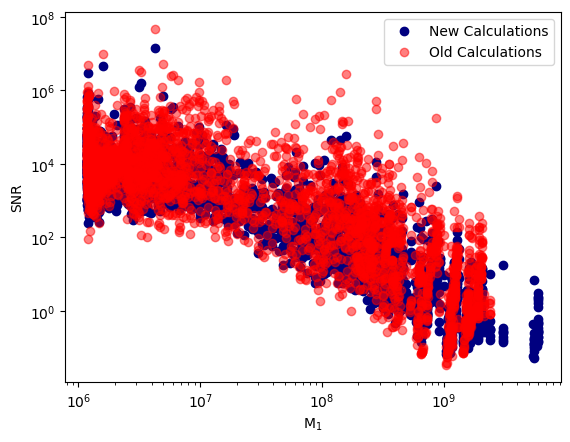

In [73]:
plt.loglog(M_1,snr_tng50_params,'o',label='New Calculations',c='navy')
plt.loglog(M_1,snr_tng50_old,'o',label='Old Calculations', c='red',alpha=.5)
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

In [74]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


/tmp/ipykernel_71124/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


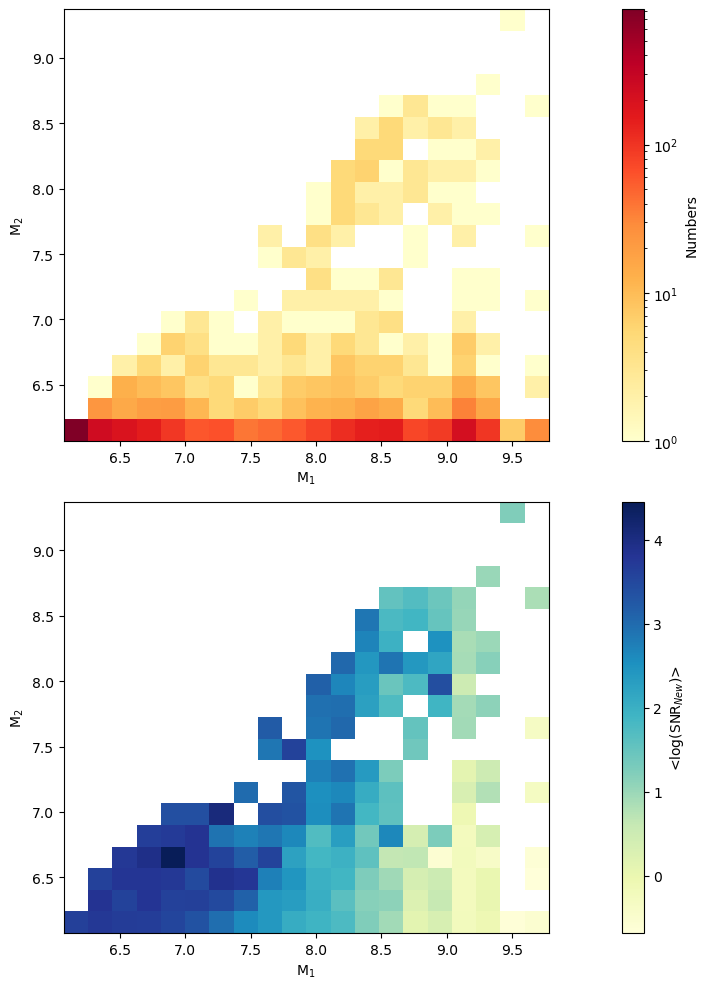

In [75]:
avg_hist(np.log10(M_1), np.log10(M_2),snr_tng50_params,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR$_{New}$)>', logweight=True,)

/tmp/ipykernel_71124/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


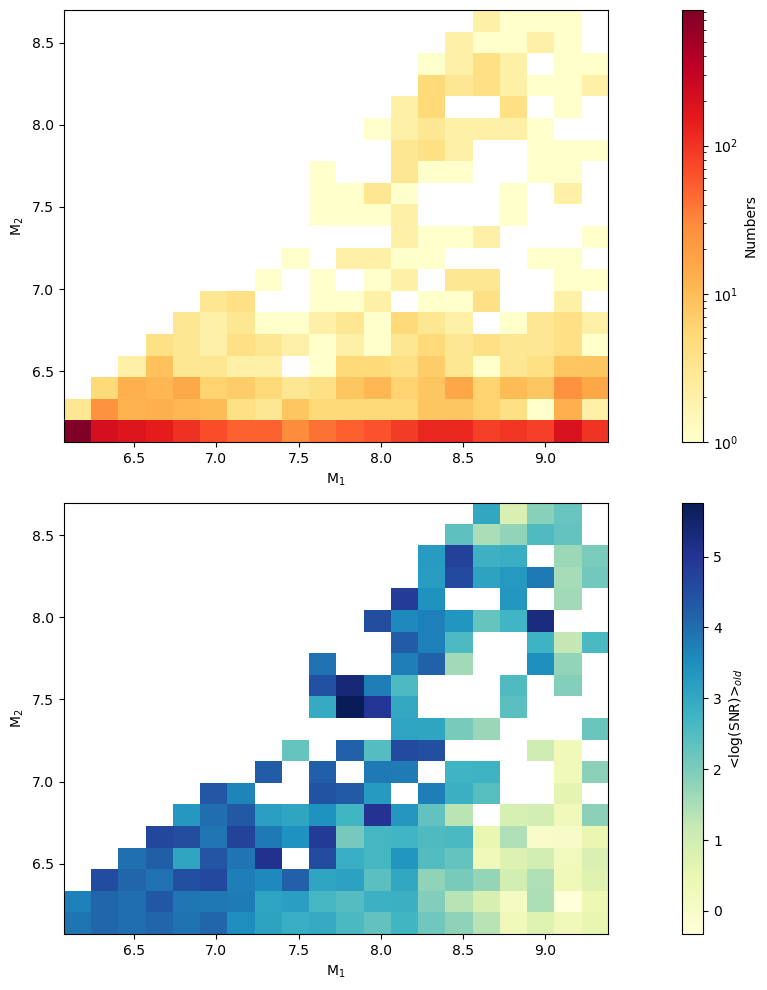

In [76]:
avg_hist(np.log10(M_1), np.log10(M_2),snr_tng50_old,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{old}$', logweight=True)

In [77]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
             num_elements = len(M_1),obs=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


In [78]:
def draw_params(m1 = M_1, 
                m2 = M_2, dist = d_l,n=1): 
                
    arr_size=len(m1)*n
    
    
    m1new = list(chain.from_iterable(repeat(x, n) for x in m1))
    m2new = list(chain.from_iterable(repeat(x, n) for x in m2))
    distnew = list(chain.from_iterable(repeat(x, n) for x in dist))
    

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

In [79]:
def random_pop(m1 = M_1, 
                m2 = M_2, dist = d_l, sample_size = 30000):

    # Generate random indices
    indices = random.sample(range(len(M_1)), sample_size)

    # Get elements from each array using the same indices
    M_1sample = np.array([m1[i] for i in indices])
    M_2sample = np.array([m2[i] for i in indices])
    d_lsample = np.array([dist[i] for i in indices])
    #SNR_sample = np.array([snr_tng300[i] for i in indices])
    
    
    result={
         'm1'  : M_1sample,
         'm2'  : M_2sample,
        'dist' : d_lsample,
    }
    return result 


In [80]:
sample_size = 30000
# Generate random indices
indices = random.sample(range(len(M_1)), sample_size)

# Get elements from each array using the same indices
M_1sample = np.array([M_1[i] for i in indices])
M_2sample = np.array([M_2[i] for i in indices])
# SNR_sample = np.array([snr_tng300[i] for i in indices])
# reduced_M_1sample=np.array([M_1[i] for i in indices])
# reduced_M_2sample=np.array([M_2[i] for i in indices])
d_lsample = np.array([d_l[i] for i in indices])
avg_hist(np.log10(M_1sample),np.log10(M_2sample),SNR_sample,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

NameError: name 'random' is not defined

In [83]:
p=draw_params()

In [85]:
snr_50=SNR_calc(**p)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

/tmp/ipykernel_71124/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


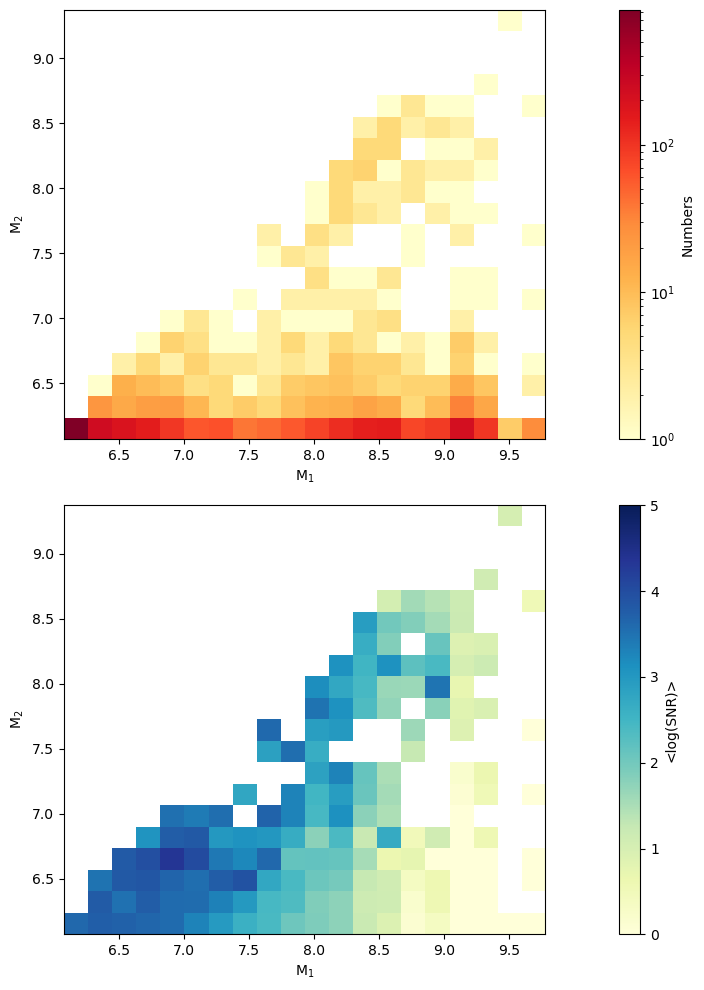

In [87]:
avg_hist(np.log10(M_1),np.log10(M_2),np.array(snr_50),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [89]:
def random_pop(m1 = M_1, 
                m2 = M_2, dist = d_l, sample_size = 2000):

    # Generate random indices
    indices = random.sample(range(len(M_1)), sample_size)

    # Get elements from each array using the same indices
    M_1sample = np.array([m1[i] for i in indices])
    M_2sample = np.array([m2[i] for i in indices])
    d_lsample = np.array([dist[i] for i in indices])
  
    
    
    result={
         'm1'  : M_1sample,
         'm2'  : M_2sample,
        'dist' : d_lsample,
    }
    return result 


In [97]:
rp=random_pop(sample_size=1000)

In [98]:
rp_params=draw_params(**rp)


In [99]:
rp_params


{'m1': [351827574.05957395,
  260268666.06353903,
  1180986.093578831,
  124650569.8773725,
  1319013.8236635206,
  1585016.2390602469,
  1190282.0048229573,
  1723752.5533253434,
  1223591.6910856932,
  728114863.0783626,
  7208754.14573965,
  1567124260.1511786,
  1620504909.4317548,
  1256524.9050803788,
  46196782.47589117,
  12190832.396524299,
  2669102.4524253495,
  267573072.73643997,
  1280975.8390521877,
  8670239.038941411,
  321288745.1716993,
  4358680.131436846,
  5778254.9072845625,
  1555580149.7541912,
  1180986.093578831,
  255943309.25944284,
  1645969.8382141422,
  6893445.463515081,
  5616651.742645147,
  2121331.5430602953,
  719691494.4671268,
  4860407.569433846,
  1536152986.3229148,
  362578974.1375892,
  2925966.956779462,
  55472835.74771593,
  19303660.76390441,
  2025804505.2229073,
  5465500432.902252,
  1220980.2302431534,
  277711840.19082266,
  2054236818.282063,
  391820193.2345374,
  1211073178.0863385,
  5838514.959666761,
  1920298168.64302,
  2073

In [100]:
snr_rp=SNR_calc(**rp_params)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

In [101]:
rp_M1=rp['m1']
rp_M2=rp['m2']

/tmp/ipykernel_71124/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


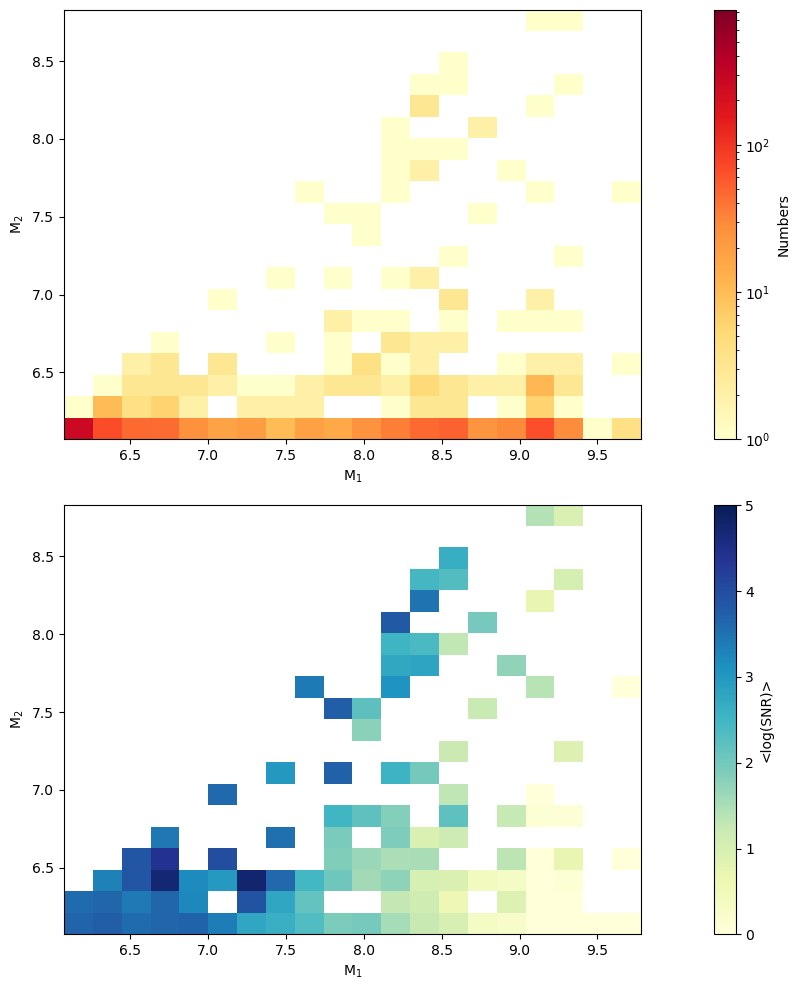

In [102]:
avg_hist(np.log10(rp_M1),np.log10(rp_M2),np.array(snr_rp),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)